In [1]:
import pandas as pd

df = pd.read_csv("Data/mental_health_diagnosis_treatment_.csv")
print(df.head())
print(df.shape)

   Patient ID  Age  Gender                  Diagnosis  \
0           1   43  Female  Major Depressive Disorder   
1           2   40  Female  Major Depressive Disorder   
2           3   55  Female  Major Depressive Disorder   
3           4   34  Female  Major Depressive Disorder   
4           5   52    Male             Panic Disorder   

   Symptom Severity (1-10)  Mood Score (1-10)  Sleep Quality (1-10)  \
0                       10                  5                     8   
1                        9                  5                     4   
2                        6                  3                     4   
3                        6                  3                     6   
4                        7                  6                     6   

   Physical Activity (hrs/week)        Medication               Therapy Type  \
0                             5  Mood Stabilizers      Interpersonal Therapy   
1                             7    Antipsychotics      Interpersonal T

In [2]:
print(df.columns)

Index(['Patient ID', 'Age', 'Gender', 'Diagnosis', 'Symptom Severity (1-10)',
       'Mood Score (1-10)', 'Sleep Quality (1-10)',
       'Physical Activity (hrs/week)', 'Medication', 'Therapy Type',
       'Treatment Start Date', 'Treatment Duration (weeks)',
       'Stress Level (1-10)', 'Outcome', 'Treatment Progress (1-10)',
       'AI-Detected Emotional State', 'Adherence to Treatment (%)'],
      dtype='str')


In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [4]:
print(df.isnull().sum())

patient_id                      0
age                             0
gender                          0
diagnosis                       0
symptom_severity_(1-10)         0
mood_score_(1-10)               0
sleep_quality_(1-10)            0
physical_activity_(hrs/week)    0
medication                      0
therapy_type                    0
treatment_start_date            0
treatment_duration_(weeks)      0
stress_level_(1-10)             0
outcome                         0
treatment_progress_(1-10)       0
ai-detected_emotional_state     0
adherence_to_treatment_(%)      0
dtype: int64


In [5]:
print(df.duplicated().sum())

0


In [6]:
print(df.dtypes)

patient_id                      int64
age                             int64
gender                            str
diagnosis                         str
symptom_severity_(1-10)         int64
mood_score_(1-10)               int64
sleep_quality_(1-10)            int64
physical_activity_(hrs/week)    int64
medication                        str
therapy_type                      str
treatment_start_date              str
treatment_duration_(weeks)      int64
stress_level_(1-10)             int64
outcome                           str
treatment_progress_(1-10)       int64
ai-detected_emotional_state       str
adherence_to_treatment_(%)      int64
dtype: object


In [20]:
df.duplicated().sum()

np.int64(0)

In [7]:
print(df.describe())

       patient_id         age  symptom_severity_(1-10)  mood_score_(1-10)  \
count  500.000000  500.000000               500.000000         500.000000   
mean   250.500000   38.708000                 7.478000           5.482000   
std    144.481833   12.712433                 1.706265           1.707486   
min      1.000000   18.000000                 5.000000           3.000000   
25%    125.750000   28.000000                 6.000000           4.000000   
50%    250.500000   38.000000                 8.000000           5.000000   
75%    375.250000   50.000000                 9.000000           7.000000   
max    500.000000   60.000000                10.000000           8.000000   

       sleep_quality_(1-10)  physical_activity_(hrs/week)  \
count            500.000000                    500.000000   
mean               6.472000                      5.216000   
std                1.668167                      2.829374   
min                4.000000                      1.000000   
2

In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "").str.replace("-", "_")
print(df.columns)

Index(['patient_id', 'age', 'gender', 'diagnosis', 'symptom_severity_1_10',
       'mood_score_1_10', 'sleep_quality_1_10', 'physical_activity_hrs/week',
       'medication', 'therapy_type', 'treatment_start_date',
       'treatment_duration_weeks', 'stress_level_1_10', 'outcome',
       'treatment_progress_1_10', 'ai_detected_emotional_state',
       'adherence_to_treatment_%'],
      dtype='str')


In [9]:
df.columns = df.columns.str.replace("/", "_").str.replace("%", "percent")
print(df.columns)

Index(['patient_id', 'age', 'gender', 'diagnosis', 'symptom_severity_1_10',
       'mood_score_1_10', 'sleep_quality_1_10', 'physical_activity_hrs_week',
       'medication', 'therapy_type', 'treatment_start_date',
       'treatment_duration_weeks', 'stress_level_1_10', 'outcome',
       'treatment_progress_1_10', 'ai_detected_emotional_state',
       'adherence_to_treatment_percent'],
      dtype='str')


In [10]:
print(df.columns)
print(df['ai_detected_emotional_state'].unique())
print(df['mood_score_1_10'].describe())

Index(['patient_id', 'age', 'gender', 'diagnosis', 'symptom_severity_1_10',
       'mood_score_1_10', 'sleep_quality_1_10', 'physical_activity_hrs_week',
       'medication', 'therapy_type', 'treatment_start_date',
       'treatment_duration_weeks', 'stress_level_1_10', 'outcome',
       'treatment_progress_1_10', 'ai_detected_emotional_state',
       'adherence_to_treatment_percent'],
      dtype='str')
<StringArray>
['Anxious', 'Neutral', 'Happy', 'Excited', 'Stressed', 'Depressed']
Length: 6, dtype: str
count    500.000000
mean       5.482000
std        1.707486
min        3.000000
25%        4.000000
50%        5.000000
75%        7.000000
max        8.000000
Name: mood_score_1_10, dtype: float64


In [11]:
order = ['Depressed', 'Stressed', 'Anxious', 'Neutral', 'Happy', 'Excited']

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='ai_detected_emotional_state', ylabel='mood_score_1_10'>

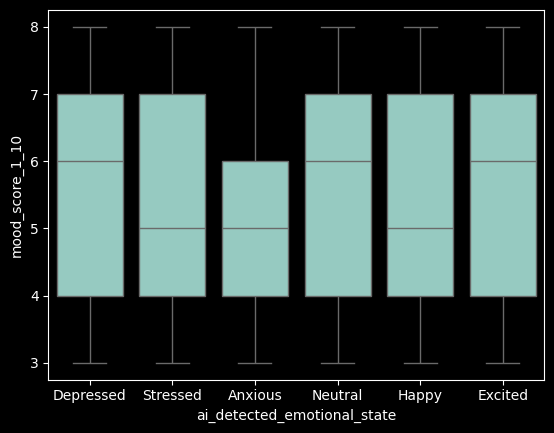

In [14]:
plt.figure()

sns.boxplot(
    x='ai_detected_emotional_state', y='mood_score_1_10', data=df, order=order
       )

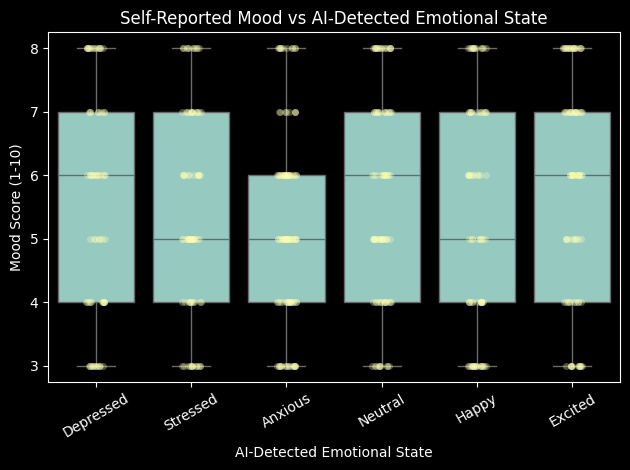

In [18]:
plt.figure()

sns.boxplot(
    x='ai_detected_emotional_state', y='mood_score_1_10', data=df, order=order
       )
sns.stripplot(
    x='ai_detected_emotional_state', y='mood_score_1_10', data=df, order=order, alpha=0.3
)
plt.title("Self-Reported Mood vs AI-Detected Emotional State")
plt.xlabel("AI-Detected Emotional State")
plt.ylabel("Mood Score (1-10)")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()